In [14]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import os
import rasterio as rio
import pickle as pkl
import random
import json

# modelling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=UserWarning)

# Setup and Dataloading

In [3]:
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'
sites = os.listdir(data_dir)
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A'] # Don't train on these
train_sites = [s for s in sites if s not in test_sites]
random.shuffle(train_sites)
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty', 'veg_class']

In [4]:
# Original data
df = pd.read_csv('dataset_file_transformed.csv')
df_reduced = df[df['class_certainty'] <= 2]

# Data with targetted labels added. Has extreme class imbalance
df_targetted = pd.read_csv('dataset_targetted_transformed.csv')
df_targetted_reduced = df_targetted[df_targetted['class_certainty'] <= 2]

# Hyperparameter Search
We use a custom CV and random search so that we can split the train and validation data by site

In [5]:
### Helper functions

# Simple dataframe splitting
def split_xy(df):
    feature_columns = [c for c in list(df.columns) if c not in non_predictive_columns]
    X = df[feature_columns]
    y = df['veg_class']
    return X, y


# More involved splitting, used when prototyping experiments
def split_by_sites(df, sites):
    site_indices = df['site'].isin(sites)

    feature_columns = [c for c in list(df.columns) if c not in non_predictive_columns]
    X = df[feature_columns]
    y = df['veg_class']
    
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test

def split_by_portion(df, portion=0.2):
    X, y = split_xy(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=portion)
    return X_train, X_test, y_train, y_test
    
def make_balanced_binary_dataset(df_unbalanced, df_supplementary, sites):
    data = df_unbalanced.copy()
    supp = df_supplementary.copy()
    data['veg_class'] = (data['veg_class'] == 1).astype(int)
    supp['veg_class'] = (supp['veg_class'] == 1).astype(int)
    for site in sites:
        site_data = data[data['site'] == site]
        site_supp = supp[(supp['site'] == site) & (supp['veg_class'] == 1)]
        
        merged = pd.merge(site_supp, site_data, how='outer', indicator=True)

        # Filter rows that are only in 'A' 
        site_supp = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
        num_pos = len(site_data[site_data['veg_class'] == 1])
        num_neg = len(site_data[site_data['veg_class'] == 0])
        supp_rows = site_supp.sample(n=min(num_neg-num_pos, len(site_supp)))
        data = pd.concat([data, supp_rows], ignore_index=True)
    
    return data


In [6]:
# Run all CV splits and return results
def site_cross_validation(model, data, run_function, cut_size):
    '''
    `cuts` is a list of lists with site names used for cross validation
          ex: [ ['CS3A', 'ZF20-11A'], ['F3-20A', 'CG1-8A'], ... ]
    `sampling_function` is used to over / under sample to get around class imbalance
    '''
    train_accuracies = []
    val_accuracies = []
    
    data_sites = data['site'].unique()
    cv_cuts = [sites[i:i + cut_size] for i in range(0, len(sites), cut_size)]
    
    print(cv_cuts)
    
    for cut in cv_cuts:
        train_data = data[~data['site'].isin(cut)]
        val_data = data[data['site'].isin(cut)]
        tr, va = run_function(model, train_data, val_data) # this is where experiment fn is called
        train_accuracies.append(tr)
        val_accuracies.append(va)
        
    return train_accuracies, val_accuracies

# Random search procedure
def random_search(data, model_class, param_dist, run_function, n_iterations=50, cut_size=4, n_jobs=8):
    '''
    data - dataframe containing all the data we want to train on
    model_class - the model class we're using for this experiment
    param_dist - dictionary with search space for random search
    run_function - custom function implementing experiment logic must have function signature:
            run_function(model, train_data, val_data) -> train_accuracy, val_accuracy:
    '''
    
    best_params = None
    best_accuracy = 0.0
    
    for i in range(n_iterations):
        params = {key: random.choice(value) for key, value in param_dist.items()}
        model = model_class(n_jobs=n_jobs, **params)
        print(f'Trying {params}')
        train_accuracies, val_accuracies = site_cross_validation(model, data, run_function, cut_size)
        
        print(f'  Val accuracies: {val_accuracies}')
        print(f'  Train accuracy mean: {mean(train_accuracies)}, Val accuracy mean: {mean(val_accuracies)}')
        if mean(val_accuracies) > best_accuracy:
            best_accuracy = mean(val_accuracies)
            best_params = params
    
    print(f'\nBest params: {best_params}. Average test accuracy: {best_accuracy}')

# Experiments
Since the data has high spatial (and site-level) autocorrelation, we have a custom procedure for running experiments.
In the above section, we defined a site-level cross-validation routine, and nested that inside a custom hyperparameter search
that uses that CV. So for each experiment, we just need to implement the core training logic.

- define a function first
  - inputs:
    - model - initialized sklearn model
    - train_data - dataframe with all data for train sites
    - val_data - dataframe with all data for validation sites
  - outputs:
    - train accuracy
    - val accuracy
  - this function will be used within the CV loop, nested inside random search

- define the data you will use (+/- targetted labels for example)
- define model type and parameter distribution

This structure allows for maximum flexibility with how you define an experiment. When prototyping, it is easiest to not use the
CV functionality, and instead structure it like this:

```
def experiment_fn(model, train_data, val_data):
    ...
    ...
    return model.score(X_res, y_res), model.score(X_train, y_train)

model = RandomForestClassifier({params})

experiment_fn(model, df[df['site'].isin(train_sites)], df[df['site'].isin(test_sites)])

```

Once the training function is working as expected, try plugging it into the random search routine.

## Baseline
- Original data (without targetted lichen labels)
- Random Forest with moderate hyperparameter search
- SMOTE oversampling for underrepresented classes

In [18]:
def experiment_fn(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    model.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    return model.score(X_res, y_res), model.score(X_val, y_val)


data = df_reduced
sites = [s for s in sites if s != 'CS3A']

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [4, 5, 6, 8, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, experiment_fn, n_iterations=10, cut_size=1)

'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

Trying {'n_estimators': 600, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1}
[['CG1-8A'], ['CG1-8B'], ['CS-103A'], ['CS-103B'], ['CS117B'], ['CS3B'], ['CS3C'], ['CS-46A'], ['CS-46B'], ['CS-59B'], ['CS-96B'], ['F3-19B'], ['F3-19C'], ['F3-20A'], ['F3-20B'], ['F3-20C'], ['F3-8A'], ['F3-8B'], ['F3-8C'], ['ZF20-11A'], ['ZF46-15A'], ['ZF46-37A'], ['ZF46-45A']]
  Val accuracies: [0.7284234752589183, 0.5994550408719346, 0.6209677419354839, 0.6909448818897638, 0.6769759450171822, 0.550561797752809, 0.4540420819490587, 0.632051282051282, 0.6705426356589147, 0.658703071672355, 0.6131301289566237, 0.6166056166056166, 0.658254468980021, 0.64, 0.7023370233702337, 0.6663244353182751, 0.6320754716981132, 0.6108998732572877, 0.585635359116022, 0.7104446742502585, 0.5358361774744027, 0.5193423597678917, 0.5633928571428571]
  Train accuracy mean: 0.6331392014830384, Val accuracy mean: 0.6233454956519697
Trying {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf'

"\nmodel = model_type(n_estimators=500, max_depth=10, n_jobs=8)\nexperiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])\n"

In [40]:
data = df_reduced.copy()
sites = [s for s in sites if s != 'CS3A']

X_train, X_test, y_train, y_test = split_by_sites(data, ['CS-103A'])

# Out-of-site model
over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
X_res, y_res = over.fit_resample(X_train, y_train)
oos_model = RandomForestClassifier(n_estimators=600, max_depth=8, min_samples_split=2, min_samples_leaf=1, n_jobs=8)
oos_model.fit(X_res.values, y_res.values)
joblib.dump(oos_model, 'oos_multi.pkl')

#In-site model
is_model = RandomForestClassifier(n_estimators=600, max_depth=8, min_samples_split=2, min_samples_leaf=1, n_jobs=8)
is_model.fit(X_test, y_test)
is_model.score(X_test, y_test)
joblib.dump(is_model, 'is_multi.pkl')

['is_multi.pkl']

### RGB Only

In [40]:
def experiment_fn(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    model.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    return model.score(X_res, y_res), model.score(X_val, y_val)

data = df_reduced.copy()
data = data[[c for c in data.columns if c not in ['chm', 'rc', 'gc', 'bc', 'rc/gc', 'rc+gc', 'Y', 'L', 'z_score_Y', 'z_score_L']]]

sites = [s for s in sites if s != 'CS3A']

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [300, 400, 500],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, experiment_fn, n_iterations=10, cut_size=1)

'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

Trying {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1}
[['CG1-8A'], ['CG1-8B'], ['CS-103A'], ['CS-103B'], ['CS117B'], ['CS3B'], ['CS3C'], ['CS-46A'], ['CS-46B'], ['CS-59B'], ['CS-96B'], ['F3-19B'], ['F3-19C'], ['F3-20A'], ['F3-20B'], ['F3-20C'], ['F3-8A'], ['F3-8B'], ['F3-8C'], ['ZF20-11A'], ['ZF46-15A'], ['ZF46-37A'], ['ZF46-45A']]
  Val accuracies: [0.5086306098964327, 0.553133514986376, 0.5564516129032258, 0.6958661417322834, 0.46964490263459335, 0.5379213483146067, 0.4418604651162791, 0.5666666666666667, 0.6059431524547804, 0.5062571103526735, 0.5181711606096131, 0.49694749694749696, 0.3911671924290221, 0.4666666666666667, 0.5387453874538746, 0.5123203285420944, 0.601078167115903, 0.5171102661596958, 0.42955801104972374, 0.3877973112719752, 0.4778156996587031, 0.3346228239845261, 0.3776785714285714]
  Train accuracy mean: 0.563667426039923, Val accuracy mean: 0.49965454819025146
Trying {'n_estimators': 400, 'max_depth': 2, 'min_samples_split': 4

"\nmodel = model_type(n_estimators=500, max_depth=10, n_jobs=8)\nexperiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])\n"

# Binary with targetted labels
also going well

In [35]:
def experiment_fn(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    # -------------------------------
    under = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority')
    X_res, y_res = under.fit_resample(X_train, y_train)
    X_val, y_val = under.fit_resample(X_val, y_val)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    model.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    return model.score(X_res, y_res), model.score(X_val, y_val)


data = make_balanced_binary_dataset(df_reduced, df_targetted_reduced, sites)


model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [4, 5, 6, 8, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, experiment_fn, n_iterations=10, cut_size=1)

'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

Trying {'n_estimators': 500, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 2}
[['CG1-8A'], ['CG1-8B'], ['CS-103A'], ['CS-103B'], ['CS117B'], ['CS3A'], ['CS3B'], ['CS3C'], ['CS-46A'], ['CS-46B'], ['CS-59B'], ['CS-96B'], ['F3-19B'], ['F3-19C'], ['F3-20A'], ['F3-20B'], ['F3-20C'], ['F3-8A'], ['F3-8B'], ['F3-8C'], ['ZF20-11A'], ['ZF46-15A'], ['ZF46-37A'], ['ZF46-45A']]
  Val accuracies: [0.5760743321718932, 0.7123893805309734, 0.7833827893175074, 0.570281124497992, 0.6857988165680473, 0.735973597359736, 0.8706896551724138, 0.7635239567233385, 0.8149671052631579, 0.6810064935064936, 0.7871165644171779, 0.7159244264507423, 0.527180783817952, 0.7634285714285715, 0.5538461538461539, 0.6645962732919255, 0.6744060475161987, 0.6334355828220859, 0.5708762886597938, 0.7251798561151079, 0.4704081632653061, 0.6244877049180327, 0.4825479930191972, 0.6108108108108108]
  Train accuracy mean: 0.6964273890456553, Val accuracy mean: 0.6665971863121087
Trying {'n_estimators': 500, 'max_depth':

"\nmodel = model_type(n_estimators=500, max_depth=10, n_jobs=8)\nexperiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])\n"

In [13]:
data = df_targetted_reduced.copy()
data['veg_class'] = (data['veg_class'] == 1).astype(int)
sites = [s for s in sites if s != 'CS3A']

X_train, X_test, y_train, y_test = split_by_sites(data, ['CS-103A'])

# Out-of-site model
under = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority')
X_res, y_res = under.fit_resample(X_train, y_train)
oos_model = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_split=4, min_samples_leaf=2, n_jobs=8)
oos_model.fit(X_res.values, y_res.values)
joblib.dump(oos_model, 'oos_bin.pkl')

#In-site model
is_model = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_split=4, min_samples_leaf=2, n_jobs=8)
is_model.fit(X_test, y_test)
is_model.score(X_test, y_test)
joblib.dump(is_model, 'is_bin.pkl')

['is_bin.pkl']

In [15]:
# Used for single experiments
def run_experiment(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train.values, y_train.values)

    # oversample w synthetic minority oversampling to balance classes
    over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)
    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = model.predict(X_test.values)

    print(f'  Train accuracy: {model.score(X_train, y_train)}')
    print(f'  Test accuracy: {model.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = model.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=model.classes_)

        feature_importance = pd.DataFrame(model.feature_importances_, index=X_train.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return clf, preds

# Site-level experiments
For each site, we want to do the following:

- Out-of-site, all features
- Out-of-site, RGB features
- In-site, all features
- In-site, RGB features

For each of those 96 experiments, we record:
- Confusion matrix
- Saved model file (.pkl)
- Dictionary of accuracies (maybe binary experiment values as well?)

In [17]:
run_dir = 'runs/all_sites'
if not os.path.exists(run_dir):
    os.makedirs(run_dir)


model_multi = RandomForestClassifier(n_estimators=600, max_depth=8, min_samples_split=2, min_samples_leaf=1, n_jobs=8)
model_bin = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_split=4, min_samples_leaf=2, n_jobs=8)
model_rgb = RandomForestClassifier(n_estimators=400, max_depth=4, min_samples_split=4, min_samples_leaf=2, n_jobs=8)

df_multi = df_reduced
df_bin = make_balanced_binary_dataset(df_reduced, df_targetted_reduced, sites)
df_rgb = df_reduced[[c for c in df_reduced.columns if c not in ['chm', 'rc', 'gc', 'bc', 'rc/gc', 'rc+gc', 'Y', 'L', 'z_score_Y', 'z_score_L']]]

def fit_and_score(model, X_train, X_test, y_train, y_test, sampling='under'):
    if sampling == 'under':
        under = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority')
        X_res, y_res = under.fit_resample(X_train, y_train)
        X_test, y_test = under.fit_resample(X_test, y_test) # undersample test data too, as there are way too many lichen labels
    elif sampling == 'over':
        over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
        X_res, y_res = over.fit_resample(X_train, y_train)

    model.fit(X_res.values, y_res.values)
    preds = model.predict(X_test.values)
    cf_matrix = confusion_matrix(y_test.values, preds, labels = model.classes_)
    cf_df = pd.DataFrame(cf_matrix, index=model.classes_, columns=model.classes_)
    cf_df.index.name = 'class'
    accuracy = model.score(X_test, y_test)
    return accuracy, cf_df

scores = {}

for site in sites:
    print(f'Scoring {site}...')
    site_dir = os.path.join(run_dir, site)
    if not os.path.exists(site_dir):
        os.makedirs(site_dir)
        os.makedirs(os.path.join(site_dir, 'out_of_site_all'))
        os.makedirs(os.path.join(site_dir, 'out_of_site_rgb'))
        os.makedirs(os.path.join(site_dir, 'in_site_all'))
        os.makedirs(os.path.join(site_dir, 'in_site_rgb'))

    # out of site, all features
    X_train, X_test, y_train, y_test = split_by_sites(df_multi, [site])
    acc, cf = fit_and_score(model_multi, X_train, X_test, y_train, y_test)
    stats = {'accuracy': acc}
    
    cf.to_csv(os.path.join(site_dir, 'out_of_site_all', 'confusion_matrix.csv'))
    joblib.dump(model_multi, os.path.join(site_dir, 'out_of_site_all', 'model.pkl'))
    with open(os.path.join(site_dir, 'out_of_site_all', 'stats.pkl'), 'w') as f:
        json.dump(stats, f)
    
 
    # out of site, RGB features
    X_train, X_test, y_train, y_test = split_by_sites(df_rgb, [site])
    acc, cf = fit_and_score(model_rgb, X_train, X_test, y_train, y_test)
    stats = {'accuracy': acc}
    
    cf.to_csv(os.path.join(site_dir, 'out_of_site_rgb', 'confusion_matrix.csv'))
    joblib.dump(model_rgb, os.path.join(site_dir, 'out_of_site_rgb', 'model.pkl'))
    with open(os.path.join(site_dir, 'out_of_site_rgb', 'stats.pkl'), 'w') as f:
        json.dump(stats, f)

    # in site, all features
    X_train, X_test, y_train, y_test = split_by_portion(df_multi[df_multi['site'] == site])
    acc, cf = fit_and_score(model_multi, X_train, X_test, y_train, y_test)
    stats = {'accuracy': acc}
    
    cf.to_csv(os.path.join(site_dir, 'in_site_all', 'confusion_matrix.csv'))
    joblib.dump(model_multi, os.path.join(site_dir, 'in_site_all', 'model.pkl'))
    with open(os.path.join(site_dir, 'in_site_all', 'stats.pkl'), 'w') as f:
        json.dump(stats, f)
    
 
    # in site, RGB features
    X_train, X_test, y_train, y_test = split_by_portion(df_rgb[df_rgb['site'] == site])
    acc, cf = fit_and_score(model_rgb, X_train, X_test, y_train, y_test)
    stats = {'accuracy': acc}
    
    cf.to_csv(os.path.join(site_dir, 'in_site_rgb', 'confusion_matrix.csv'))
    joblib.dump(model_rgb, os.path.join(site_dir, 'in_site_rgb', 'model.pkl'))
    with open(os.path.join(site_dir, 'in_site_rgb', 'stats.pkl'), 'w') as f:
        json.dump(stats, f)
    
    

Scoring CG1-8A...
Scoring CG1-8B...
Scoring CS-103A...
Scoring CS-103B...
Scoring CS117B...
Scoring CS3A...
Scoring CS3B...
Scoring CS3C...
Scoring CS-46A...
Scoring CS-46B...
Scoring CS-59B...
Scoring CS-96B...
Scoring F3-19B...
Scoring F3-19C...
Scoring F3-20A...
Scoring F3-20B...
Scoring F3-20C...
Scoring F3-8A...
Scoring F3-8B...
Scoring F3-8C...
Scoring ZF20-11A...
Scoring ZF46-15A...
Scoring ZF46-37A...
Scoring ZF46-45A...


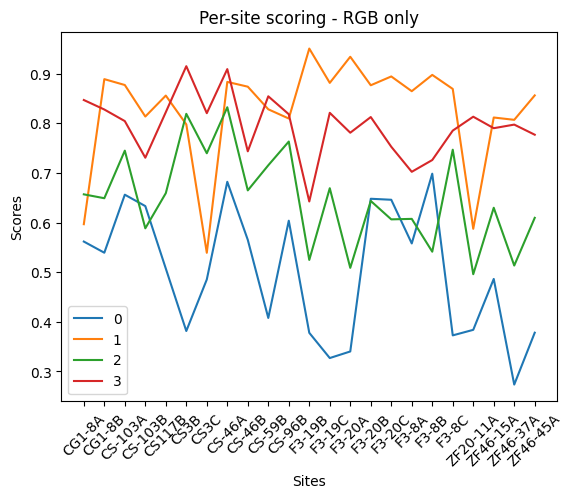

In [39]:

num_points = len(next(iter(scores.values())))
for i in range(num_points):
    line_data = [values[i] for values in scores.values()]
    plt.plot(list(scores.keys()), line_data, label=f'{i}')

plt.legend()
plt.xlabel('Sites')
plt.ylabel('Scores')
plt.title('Per-site scoring - RGB only')
plt.xticks(rotation=45)
plt.show()

# blue - multilabel, out-of-site
# orange - multilabel, in-site
# green - binary, out-of-site
# red - binary, in-sitez

In [40]:
import csv

data = scores
# Create a list of labels based on the number of points in the data lists
num_points = len(next(iter(data.values())))
labels = ['site','oos-multilabel','is-multilabel','oos-binary','is-binary']

# Prepare the data to be written to the CSV
rows = []
for key, values in data.items():
    row = [key] + values
    rows.append(row)

# Write the data to a CSV file
filename = "scores_rgb_only.csv"
with open(filename, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    
    # Write the header
    csvwriter.writerow(labels)
    
    # Write the rows
    csvwriter.writerows(rows)

print(f"Data written to {filename}")

Data written to scores_rgb_only.csv


In [41]:
X_train

,R,G,B,ExG,ExR,ExB,ExGmExR,Ikaw,MGRVI,GLI
245806,0.529412,0.631373,0.419608,0.313725,0.109804,-0.043922,0.203922,0.115702,0.174331,0.141844
244962,0.768627,0.784314,0.815686,-0.015686,0.291765,0.357647,-0.307451,-0.029703,0.020200,-0.004975
246357,0.298039,0.274510,0.176471,0.074510,0.142745,-0.027451,-0.068235,0.256198,-0.082053,0.072797
245311,0.278431,0.396078,0.188235,0.325490,-0.006275,-0.132549,0.331765,0.193277,0.338538,0.258567
245404,0.494118,0.411765,0.352941,-0.023529,0.280000,0.082353,-0.303529,0.166667,-0.180328,-0.014085
...,...,...,...,...,...,...,...,...,...,...
246131,0.505882,0.576471,0.325490,0.321569,0.131765,-0.120784,0.189804,0.216981,0.129882,0.162055
246217,0.474510,0.568627,0.345098,0.317647,0.095686,-0.085490,0.221961,0.157895,0.178994,0.162325
246313,0.811765,0.756863,0.749020,-0.047059,0.379608,0.291765,-0.426667,0.040201,-0.069914,-0.015306
246370,0.666667,0.690196,0.600000,0.113725,0.243137,0.149804,-0.129412,0.052632,0.034672,0.042963


# Qualitative Evaluation
If you use these cells, make sure you ran the `2_process_validation_site.ipynb` notebook. Then use the code below to run inference on a whole site.

In [1]:
site = 'CS-103A'
run_name = f'{site}_01'

# location of raw lichen data
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'

# place where we stored chunked feature data
run_dir = f'/network/scratch/m/matthew.fortier/runs/{run_name}'

In [ ]:
site = 'CS-103A'
blocks = 4
chm = 3 # hard coded index of chm data

rgb_file = os.path.join(data_dir, site, f'{site}_hp_transparent_mosaic_group1.tif')

with rio.open(rgb_file) as f:
    meta = f.meta

for model_type in ['oos_multi', 'is_multi', 'oos_bin', 'is_bin']:
    print(f'Processing site using {model_type}...')
    model = joblib.load(f'{model_type}.pkl')
    curr_y = 0
    curr_x = 0
    h = 0
    w = 0

    output = np.zeros((meta['height'], meta['width']))
    for y in range(blocks):
        for x in range(blocks):
            print(f'  Processing block {y}-{x}')

            file_path = os.path.join(run_dir, 'composite', f'chunk_{y}_{x}.pkl')
            if not os.path.isfile(file_path):
                curr_x += w
                continue

            with open(file_path, "rb") as file:
                # Use pickle.load() to read the dictionary from the file
                block = pkl.load(file)
            h = block.shape[1]
            w = block.shape[2]

            block_output = np.zeros((h, w))

            # get coordinates of relevant pixels
            py, px = np.where(block[chm] >= 0)
            if len(py) > 0:
                features = block[:, py, px].T
                block_output[py, px] = model.predict(features)
                output[curr_y:curr_y+h, curr_x:curr_x+w] = block_output
                del features

            curr_x += w
            del block, block_output, py, px

        curr_x = 0
        curr_y += h

    out_file = os.path.join(run_dir, 'output', f'{model_type}.tif')

    meta.update(count=1)

    # Write a new .tif file using the metadata from the original file
    with rio.open(out_file, 'w', **meta) as dst:
        dst.write(output, 1)

Processing site using oos_multi...
  Processing block 0-0
  Processing block 0-1
  Processing block 0-2
  Processing block 0-3
  Processing block 1-0
  Processing block 1-1
  Processing block 1-2
  Processing block 1-3
  Processing block 2-0
  Processing block 2-1
  Processing block 2-2
  Processing block 2-3
  Processing block 3-0
  Processing block 3-1
  Processing block 3-2
  Processing block 3-3
Processing site using is_multi...
  Processing block 0-0
  Processing block 0-1
  Processing block 0-2
  Processing block 0-3
  Processing block 1-0
  Processing block 1-1
  Processing block 1-2
  Processing block 1-3
  Processing block 2-0
  Processing block 2-1
  Processing block 2-2
  Processing block 2-3
  Processing block 3-0
  Processing block 3-1
  Processing block 3-2
  Processing block 3-3
Processing site using oos_bin...
  Processing block 0-0
  Processing block 0-1
  Processing block 0-2
  Processing block 0-3
  Processing block 1-0
  Processing block 1-1
  Processing block 1-2
 

# Misc code
Old code that I'm keeping around in case I need to refer back to it.

In [ ]:
conf_matrix = confusion_matrix(y_targ, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
pd.DataFrame(y_pred).value_counts()

In [ ]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [ ]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 